## Python For Machine Learning Fall 2025
---
# Linear Models in Machine Learning

## 1. Overview

Linear models are the foundation of classical machine learning and are still one of the most widely used families of algorithms today. Their popularity comes from their **simplicity, interpretability, and high efficiency**.

### 1.1. What is a Linear Model?

At its core, a linear model makes a prediction by computing a simple **weighted sum of the input features**. The model "learns" the best weights (or *coefficients*) for each feature during the training process.

### The Core Equation

The underlying formula for all linear models is a linear combination:

$$
\text{prediction} = w_1x_1 + w_2x_2 + \dots + w_nx_n + b
$$

* $x_1, x_2, \dots, x_n$ are the **input features** (e.g., age, square footage, income).
* $w_1, w_2, \dots, w_n$ are the **coefficients** (weights) that the model learns. Each $w$ represents the importance of its corresponding feature.
* $b$ is the **bias** term (or *intercept*), which allows the model to have a non-zero output even when all features are zero.

The goal of training is to find the optimal values for the $w$'s and $b$ that best fit the training data.


### 1.2. Why Use Linear Models?

**Fast & Scalable:** They are very fast to train and predict, and they scale well to extremely large datasets.

**Interpretable:** They are highly interpretable. You can directly inspect the coefficients ($w$) to understand *how much* each feature contributes to the prediction and in *what direction* (positive or negative).

**Excellent Baseline:** They serve as a fantastic "baseline model." You should almost always try a linear model first to see how well it performs. If a complex model (like a neural network) can't significantly beat a simple linear model, the extra complexity is probably not worth it.

**Foundation for Other Models:** Many complex models (like Support Vector Machines and even Neural Networks) are built upon the same fundamental ideas.

### 1.3. Common Types of Linear Models

Linear models are not just one algorithm; they are a family of algorithms used for both regression and classification.

#### 1.3.1 For Regression (Predicting a Number)

The prediction is the direct output of the linear equation.

* **Linear Regression (Ordinary Least Squares):** The classic. It finds the weights that minimize the sum of the squared differences between the predicted values and the actual values.
* **Ridge Regression (L2 Regularization):** A modification that adds a penalty to prevent the weights from becoming too large. This is excellent for preventing **overfitting** and handling features that are correlated.
* **Lasso Regression (L1 Regularization):** Also adds a penalty, but one that can shrink some feature weights to **exactly zero**. This makes it incredibly useful for **automatic feature selection**.

#### 1.3.2 For Classification (Predicting a Category)

The linear equation's output ($z$) is passed through a **link function** to make a final decision.

* **Logistic Regression:** The most common linear classifier. It passes the weighted sum through a **sigmoid (logistic) function**, which squashes the output into a probability (a value between 0 and 1). This is still a linear model because the core calculation (the *log-odds*) is a linear combination of the features.
* **Linear Support Vector Machines (SVM):** Finds the "best" linear boundary (hyperplane) that creates the widest possible margin between the two classes. It's a powerful and robust classifier.
* **Linear Discriminant Analysis (LDA):** A *generative* model that first models the distribution of each class (assuming they are Gaussian) and then uses Bayes' theorem to find a linear decision boundary.

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split, \
                                    cross_val_score, \
                                    GridSearchCV
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression, LinearRegression
from sklearn.discriminant_analysis import LinearDiscriminantAnalysis
from sklearn.svm import SVC
from sklearn.datasets import make_classification, \
                             make_moons, \
                             make_blobs
from sklearn.metrics import confusion_matrix, \
                            accuracy_score, \
                            precision_score, \
                            recall_score, \
                            f1_score, \
                            roc_curve, auc, \
                            classification_report
import warnings

warnings.filterwarnings('ignore')
%matplotlib inline

## 2. Logistic Regression

The name "Logistic Regression" is one of the most confusing in machine learning, as the model is used for **classification**, not regression.

The name comes from its two separate components:

**"Logistic"**
The model is named after its core component: the **Logistic Function**.

* **What it is:** The logistic function, also known as the **sigmoid function**, is a mathematical function that creates a characteristic "S-shaped" curve.
* **What it does:** It takes any real-valued number (from $-\infty$ to $+\infty$) and "squashes" it into a value between 0 and 1.
* **Why it's used:** This "squashing" is perfect for classification. The model's internal linear equation (which you'll see below) produces a raw number. By passing this number through the logistic function, we get a clean output that can be interpreted as a **probability** (e.g., a 0.8 output means an 80% probability of belonging to Class 1).

The term "logistic" (French: *logistique*) was first coined in the 1840s by the Belgian mathematician Pierre-François Verhulst. He used this S-shaped curve to model population growth—a process that starts exponentially, then slows down as it approaches a "carrying capacity."

**"Regression"**.

This part is the source of the confusion, but it makes sense from a statistical perspective.

Logistic regression is a type of **Generalized Linear Model (GLM)**. Unlike Linear Regression, which directly regresses the *value* of $Y$ on $X$, logistic regression models something else.

It performs a linear regression on the **log-odds (or "logit") of the probability**.

Here's the breakdown:
1.  **Probability (P):** The probability of an event happening (e.g., $P(\text{spam}) = 0.8$).
2.  **Odds:** The ratio of the probability of the event happening to it *not* happening. (e.g., $\text{Odds} = \frac{P}{1-P} = \frac{0.8}{0.2} = 4$, or "4 to 1 odds").
3.  **Log-Odds (Logit):** The natural logarithm of the odds (e.g., $\ln(4) \approx 1.386$).

**This is the key:** The "regression" in the name means we are performing a *linear regression* to find the **log-odds**:

$$
\underbrace{\ln\left(\frac{P}{1-P}\right)}_{\text{Log-Odds (Logit)}} = \underbrace{w_1x_1 + w_2x_2 + \dots + w_nx_n + b}_{\text{A Linear Regression Equation}}
$$

So, "Logistic Regression" is a statistical method that uses a **linear regression** model to predict the **log-odds**, which are then transformed by the **logistic function** to give a probability used for classification.

### 2.1. From Regression to Classification: Why linear regression fails

Linear regression predicts a continuous value (e.g., price, temperature). If we try to use it for a binary classification task (e.g., Yes/No, 0/1), it fails for several reasons:

1.  **Output Range:** Linear regression outputs values from $-\infty$ to $+\infty$, but classification requires a probability (between 0 and 1) or a discrete class label.
2.  **Sensitivity to Outliers:** An outlier can dramatically shift the "best-fit" line, moving the decision boundary and causing misclassifications.
3.  **Misinterpretation:** What does an output of 0.5, 1.7, or -0.2 mean in a binary 0/1 context?

We need a model that outputs a probability. This is where Logistic Regression comes in.

In [2]:
def plot_model(X, y, model, threshold=0.5, title=""):
    # Plot the raw data points
    plt.scatter(X, y, c=y, cmap='coolwarm', s=50, edgecolors='k')

    # Generate points for the model's line
    X_fit = np.linspace(min(X) - 2, max(X) + 2, 300).reshape(-1, 1)

    if isinstance(model, LinearRegression):
        y_fit = model.predict(X_fit)
        model_type = "Linear Regression"
    else:
        y_fit = model.predict_proba(X_fit)[:, 1] # Get probability of class 1
        model_type = "Logistic Regression"

    # Plot the model's decision line/curve
    plt.plot(X_fit, y_fit, color='green', linewidth=2, label=model_type)

    # Plot the 0.5 decision boundary
    plt.axhline(threshold, color='black', linestyle='--', label=f'Threshold ({threshold})')

    # Make predictions based on the threshold
    if isinstance(model, LinearRegression):
        y_pred = (model.predict(X) > threshold).astype(int)
    else:
        y_pred = model.predict(X)

    acc = accuracy_score(y, y_pred)

    plt.title(f"{title}\nAccuracy: {acc:.2f}")
    plt.xlabel("Feature (X)")
    plt.ylabel("Class (0 or 1)")
    plt.legend()
    plt.grid(True, linestyle=':', alpha=0.6)
    plt.ylim(-0.2, 1.2) # Set y-axis limits for clarity
    plt.show()

Let's create a simple, clearly separated dataset that is entirely valid. For instance, a student who has studied for more than 5 hours will pass the exam, while those who have not will fail.

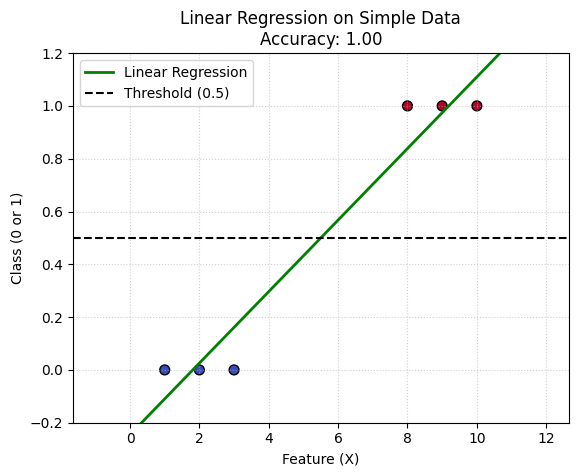

In [3]:
X_simple = np.array([1, 2, 3, 8, 9, 10]).reshape(-1, 1)
y_simple = np.array([0, 0, 0, 1, 1, 1])

lin_reg = LinearRegression().fit(X_simple, y_simple)

# Plot the result
plot_model(X_simple, y_simple, lin_reg,
           title="Linear Regression on Simple Data")

In this simple case, linear regression... seems to work! The green line crosses our 0.5 threshold right in the middle, and the accuracy is 100%.

Now, let's add just one more data point from Class 1, but further to the right (e.g., a student who studied for 25 hours and also passed). This is a perfectly valid data point, not an error.

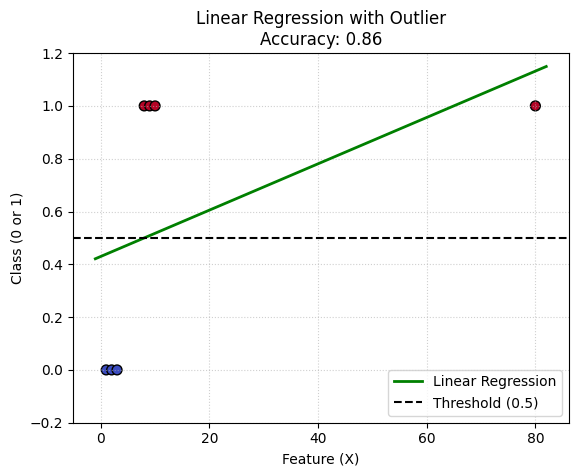

In [4]:
# Add one "outlier" data point
X_outlier = np.array([1, 2, 3, 8, 9, 10, 80]).reshape(-1, 1)
y_outlier = np.array([0, 0, 0, 1, 1, 1, 1]) # The new point is also class 1

# Fit a new Linear Regression model
lin_reg_outlier = LinearRegression().fit(X_outlier, y_outlier)

# Plot the new result
plot_model(X_outlier, y_outlier, lin_reg_outlier, title="Linear Regression with Outlier")

To minimize the squared error for the new point at X=80, the entire regression line was pulled "flatter". The decision boundary (where the green line crosses the black dashed line) has shifted so far to the right that the point at X=8 is now misclassified as Class 0. Our accuracy dropped to 86%. This is the fundamental weakness: linear regression is sensitive to outliers and will compromise its "decision boundary" to chase faraway points.

Now, let's fit a Logistic Regression model to that same "bad" dataset with the outlier.

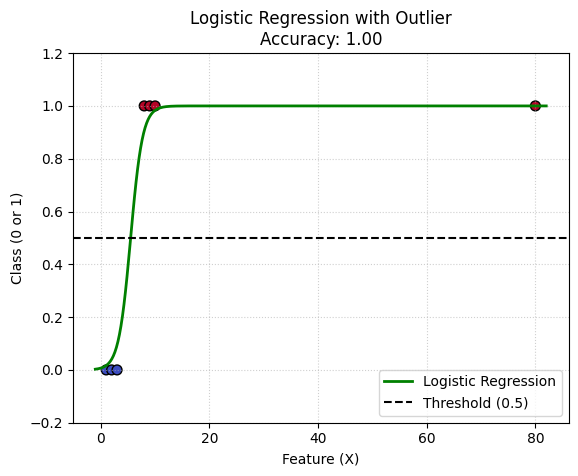

In [5]:
# Fit Logistic Regression on the "bad" data
log_reg = LogisticRegression().fit(X_outlier, y_outlier)

# Plot the logistic regression result
plot_model(X_outlier, y_outlier, log_reg, title="Logistic Regression with Outlier")

The accuracy is 100% again. The logistic regression's "S-shaped" (sigmoid) curve is not skewed by the outlier.


Logistic regression doesn't output a raw number; it outputs a probability.

Its "log-loss" function doesn't care how correct a point is, just that it's correct. The model is already "very confident" that the point at X=25 is Class 1 (its probability is ≈1.0).

Because the loss function "saturates" at 1, the outlier at X=25 has very little influence on the decision boundary, which stays exactly where it should be to separate the two main clusters.

### 2.2. The Sigmoid Function

Logistic Regression solves this problem by taking the output of a linear equation ($z = w \cdot x + b$) and passing it through a **sigmoid (or logistic) function**. This function "squashes" any input value to an output between 0 and 1.

**Equation:** $\sigma(z) = \frac{1}{1 + e^{-z}}$

-   If $z$ is large and positive, $e^{-z} \to 0$, so $\sigma(z) \to 1$.
-   If $z$ is large and negative, $e^{-z} \to \infty$, so $\sigma(z) \to 0$.
-   If $z = 0$, $\sigma(z) = 1 / (1 + 1) = 0.5$.

This output can be directly interpreted as the probability of the positive class.

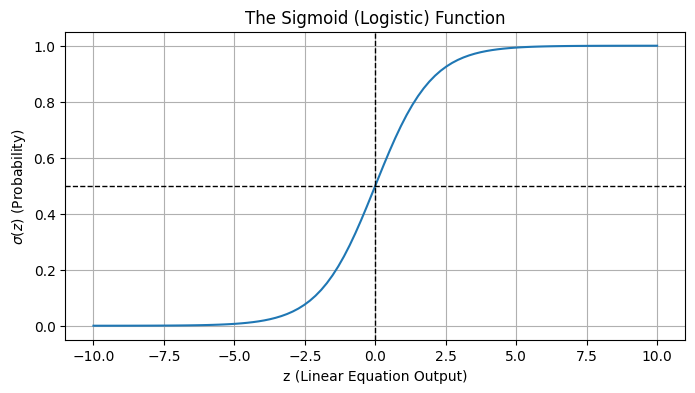

In [6]:
# Plotting the Sigmoid function
z = np.linspace(-10, 10, 100)
sigma = 1 / (1 + np.exp(-z))

plt.figure(figsize=(8, 4))
plt.plot(z, sigma)
plt.title('The Sigmoid (Logistic) Function')
plt.xlabel('z (Linear Equation Output)')
plt.ylabel('$\sigma(z)$ (Probability)')
plt.grid(True)
plt.axvline(0, color='black', linestyle='--', lw=1)
plt.axhline(0.5, color='black', linestyle='--', lw=1)
plt.show()

### 2.3. Decision Boundary

We can classify a new point based on this probability. A common threshold is 0.5.

-   If $P(y=1 | x) = \sigma(z) \ge 0.5$, predict class 1.
-   If $P(y=1 | x) = \sigma(z) < 0.5$, predict class 0.

Since $\sigma(z) = 0.5$ when $z = 0$, the decision boundary is the line (or hyperplane in higher dimensions) where the linear equation $z = w \cdot x + b = 0$. This is why Logistic Regression is a **linear classifier**.

### 2.4. Cost Function for Classification: Binary Cross-Entropy (Log Loss)

We can't use Mean Squared Error (MSE) like in linear regression because the sigmoid function makes the cost function non-convex (full of local minima).

Instead, we use **Binary Cross-Entropy**, or **Log Loss**. This function penalizes the model heavily when it makes a confident, incorrect prediction.

$Cost(h_\theta(x), y) = -y \log(h_\theta(x)) - (1-y) \log(1 - h_\theta(x))$

-   If $y=1$ (true class is 1): $Cost = -\log(h_\theta(x))$. If the model predicts $h_\theta(x) \to 0$ (wrong), cost $\to \infty$. If it predicts $h_\theta(x) \to 1$ (correct), cost $\to 0$.
-   If $y=0$ (true class is 0): $Cost = -\log(1 - h_\theta(x))$. If the model predicts $h_\theta(x) \to 1$ (wrong), cost $\to \infty$. If it predicts $h_\theta(x) \to 0$ (correct), cost $\to 0$.

### 2.5. Implementation: Using `LogisticRegression` from `sklearn`

Let's implement Logistic Regression on a simple synthetic dataset.

Logistic Regression Model Accuracy: 1.0000


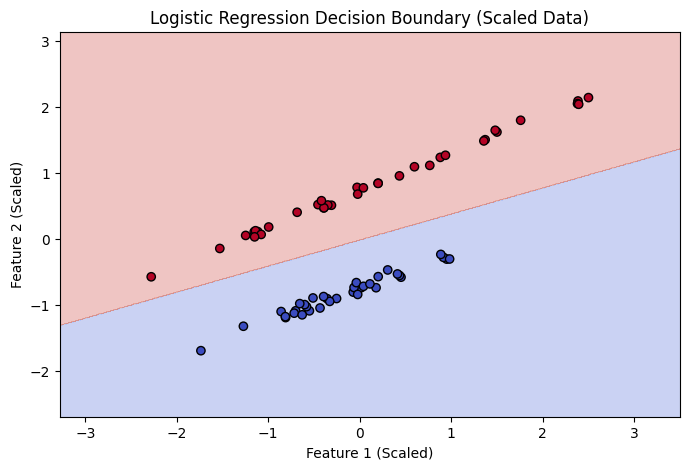

In [7]:
# 1. Create a synthetic dataset
X, y = make_classification(n_samples=100, n_features=2, n_informative=2, n_redundant=0,
                           n_clusters_per_class=1, random_state=42)

# 2. Split the data
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42)

# 3. Scale the data (Good practice for many models, including LogReg with regularization)
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# 4. Create and train the model
# 'solver' is the algorithm used for optimization
# 'C' is the inverse of regularization strength (like in SVMs)
log_reg = LogisticRegression(solver='liblinear', C=1.0)
log_reg.fit(X_train_scaled, y_train)

# 5. Make predictions
y_pred_log_reg = log_reg.predict(X_test_scaled)

# 6. Evaluate
accuracy = accuracy_score(y_test, y_pred_log_reg)
print(f'Logistic Regression Model Accuracy: {accuracy:.4f}')

# Helper function to visualize the decision boundary
def plot_decision_boundary(model, X, y, title):
    x_min, x_max = X[:, 0].min() - 1, X[:, 0].max() + 1
    y_min, y_max = X[:, 1].min() - 1, X[:, 1].max() + 1
    xx, yy = np.meshgrid(np.arange(x_min, x_max, 0.01),
                         np.arange(y_min, y_max, 0.01))

    Z = model.predict(np.c_[xx.ravel(), yy.ravel()])
    Z = Z.reshape(xx.shape)

    plt.figure(figsize=(8, 5))
    plt.contourf(xx, yy, Z, alpha=0.3, cmap=plt.cm.coolwarm)
    plt.scatter(X[:, 0], X[:, 1], c=y, cmap=plt.cm.coolwarm, edgecolors='k')
    plt.title(title)
    plt.xlabel('Feature 1 (Scaled)')
    plt.ylabel('Feature 2 (Scaled)')
    plt.show()

# Plot the decision boundary for Logistic Regression
plot_decision_boundary(log_reg, X_train_scaled, y_train, 'Logistic Regression Decision Boundary (Scaled Data)')

### 2.6. Model Evaluation

Let's calculate these metrics for our Logistic Regression model.

Confusion Matrix:
 [[15  0]
 [ 0 15]]

Classification Report:
               precision    recall  f1-score   support

           0       1.00      1.00      1.00        15
           1       1.00      1.00      1.00        15

    accuracy                           1.00        30
   macro avg       1.00      1.00      1.00        30
weighted avg       1.00      1.00      1.00        30



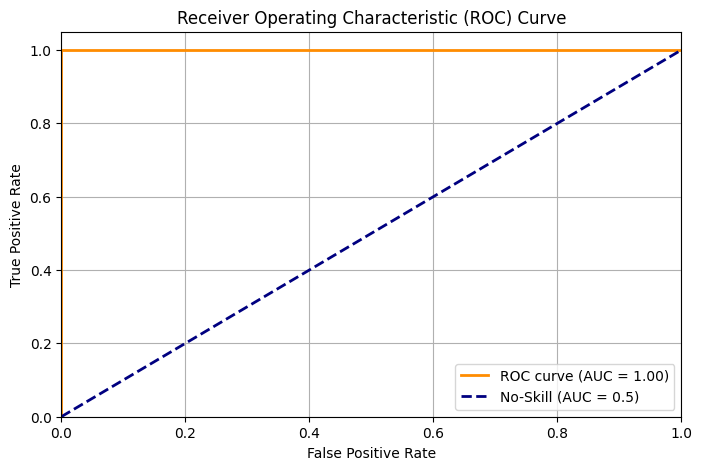

In [8]:
# 1. Get the Confusion Matrix
cm = confusion_matrix(y_test, y_pred_log_reg)
print("Confusion Matrix:\n", cm)

# 2. Get the full classification report
print("\nClassification Report:\n", classification_report(y_test, y_pred_log_reg))

# 3. Calculate ROC and AUC
# We need the predicted probabilities for the positive class
y_prob_log_reg = log_reg.predict_proba(X_test_scaled)[:, 1]

fpr, tpr, thresholds = roc_curve(y_test, y_prob_log_reg)
roc_auc = auc(fpr, tpr)

# 4. Plot ROC Curve
plt.figure(figsize=(8, 5))
plt.plot(fpr, tpr, color='darkorange', lw=2, label=f'ROC curve (AUC = {roc_auc:.2f})')
plt.plot([0, 1], [0, 1], color='navy', lw=2, linestyle='--', label='No-Skill (AUC = 0.5)')
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('Receiver Operating Characteristic (ROC) Curve')
plt.legend(loc="lower right")
plt.grid(True)
plt.show()

## 3. XOR Problem

The **XOR (Exclusive OR)** problem is a famous benchmark in machine learning because it's the simplest example of a problem that is **not linearly separable**.

In simple terms, a linear model (like Logistic Regression) works by drawing a single straight line to separate two classes. The XOR dataset is designed so that no single straight line can *ever* do this.

Here's the "truth table" for XOR:

| Input 1 ($x_1$) | Input 2 ($x_2$) | Output ($y$) |
| :---: | :---: | :---: |
| 0 | 0 | **0** |
| 0 | 1 | **1** |
| 1 | 0 | **1** |
| 1 | 1 | **0** |

The rule is: the output is '1' *only if* the inputs are different.

Let's create this dataset.

In [9]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score
from matplotlib.colors import ListedColormap

# Create the XOR dataset
X = np.array([
    [0, 0],
    [0, 1],
    [1, 0],
    [1, 1]
])

y = np.array([0, 1, 1, 0])

print("Feature data (X):")
print(X)
print("\nLabels (y):")
print(y)

Feature data (X):
[[0 0]
 [0 1]
 [1 0]
 [1 1]]

Labels (y):
[0 1 1 0]


---

### 3.1. Visualizing the Problem

Now, let's plot these four data points. We'll color the '0' class points blue and the '1' class points red.

When you look at the plot, try to imagine drawing **one single straight line** that can successfully separate the red points from the blue points.

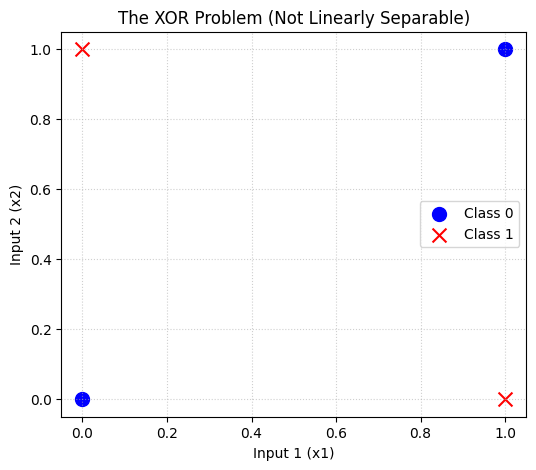

In [10]:
# Plot the data
plt.figure(figsize=(6, 5))
plt.scatter(X[y == 0][:, 0], X[y == 0][:, 1], c='blue', marker='o', s=100, label='Class 0')
plt.scatter(X[y == 1][:, 0], X[y == 1][:, 1], c='red', marker='x', s=100, label='Class 1')

plt.title("The XOR Problem (Not Linearly Separable)")
plt.xlabel("Input 1 (x1)")
plt.ylabel("Input 2 (x2)")
plt.legend()
plt.grid(True, linestyle=':', alpha=0.6)
plt.show()

### 3.2. Applying Logistic Regression

Let's train a standard Logistic Regression model on the 2D data. The model's entire goal is to find the **single best straight line** to separate the two classes.

After training, we can look at the model's learned parameters. The "decision boundary" is the line where the model is most uncertain (probability = 0.5). For logistic regression, this is the line defined by the equation:

$$
(w_1 \cdot x_1) + (w_2 \cdot x_2) + b = 0
$$

We can get these $w$ (coefficients) and $b$ (intercept) values directly from the model and check its accuracy.

In [11]:
# 1. Create and fit the model
model = LogisticRegression(solver='lbfgs', random_state=42)
model.fit(X, y)

# 2. Get the learned parameters
w = model.coef_[0]
b = model.intercept_[0]

print(f"Learned Weights (w1, w2): {w}")
print(f"Learned Intercept (b): {b}")

# 3. Check the accuracy
y_pred = model.predict(X)
accuracy = accuracy_score(y, y_pred)
print(f"\nModel Accuracy: {accuracy * 100}%")

Learned Weights (w1, w2): [0. 0.]
Learned Intercept (b): 0.0

Model Accuracy: 50.0%


### 3.3. Visualizing the (Failed) Result

An accuracy of 50% is no better than random guessing. Also, it isn't possible to plot the *exact* line the model learned, which is expected to be:

$x_2 = \frac{-(w_1 \cdot x_1) - b}{w_2}$

The XOR problem is unsolvable for a linear model. The logistic regression algorithm tries its best and fails, concluding the "best" solution is a flat plane that predicts 50% for everything. To do this, it learns that the features don't matter and sets its parameters (weights and intercept) to zero (or extremely tiny numbers close to zero).

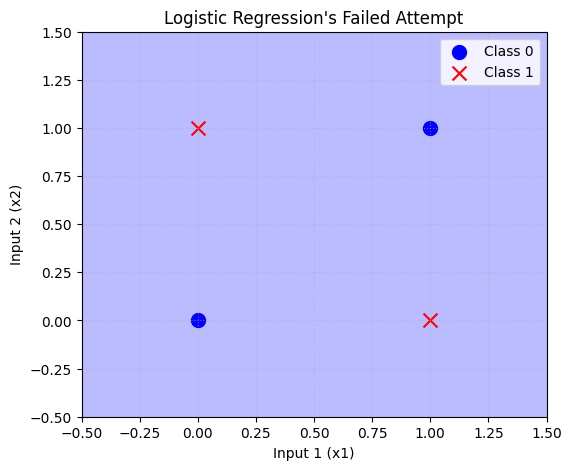

In [12]:
from matplotlib.colors import ListedColormap

x_min, x_max = X[:, 0].min() - 0.5, X[:, 0].max() + 0.5
y_min, y_max = X[:, 1].min() - 0.5, X[:, 1].max() + 0.5

# Create a grid of points (e.g., 500x500)
xx, yy = np.meshgrid(np.linspace(x_min, x_max, 500),
                     np.linspace(y_min, y_max, 500))

# Get predictions for every point on the grid
# np.c_ creates a 2-column array from the flattened xx and yy grids
Z = model.predict(np.c_[xx.ravel(), yy.ravel()])
Z = Z.reshape(xx.shape) # Reshape predictions back to grid shape

# Define a color map for the regions
cmap_light = ListedColormap(['#AAAAFF', '#FFAFAF']) # Blue and Red regions

plt.figure(figsize=(6, 5))

# Plot the decision regions
plt.contourf(xx, yy, Z, cmap=cmap_light, alpha=0.8)

# Plot the original data points
plt.scatter(X[y == 0][:, 0], X[y == 0][:, 1], c='blue', marker='o', s=100, label='Class 0')
plt.scatter(X[y == 1][:, 0], X[y == 1][:, 1], c='red', marker='x', s=100, label='Class 1')

plt.title("Logistic Regression's Failed Attempt")
plt.xlabel("Input 1 (x1)")
plt.ylabel("Input 2 (x2)")
plt.legend()
plt.grid(True, linestyle=':', alpha=0.6)
plt.show()

This is the key limitation of all linear classifiers and the reason the XOR problem is so important: it proves that we need more powerful, **non-linear** models (like SVMs with kernels, or Neural Networks) to solve complex, real-world problems.

## 4. Support Vector Machines (SVM)

Support Vector Machine (SVM) is a powerful and versatile supervised machine learning algorithm used for both classification and regression. However, it is most famous for its use in classification.

The core idea of SVM is to find the **optimal hyperplane** (a line in 2D, a plane in 3D, etc.) that best separates the classes in the feature space.

### 4.1. The Maximal Margin Classifier

The key difference is the **objective**:
-   **Logistic Regression:** Finds a line that best fits the *probabilities*.
-   **SVM:** Finds the line that **maximizes the margin**.

The **margin** is the distance between the decision hyperplane and the nearest data points from either class. Think of it as the "street" or "buffer zone" between the classes. SVM tries to find the *widest possible street*.

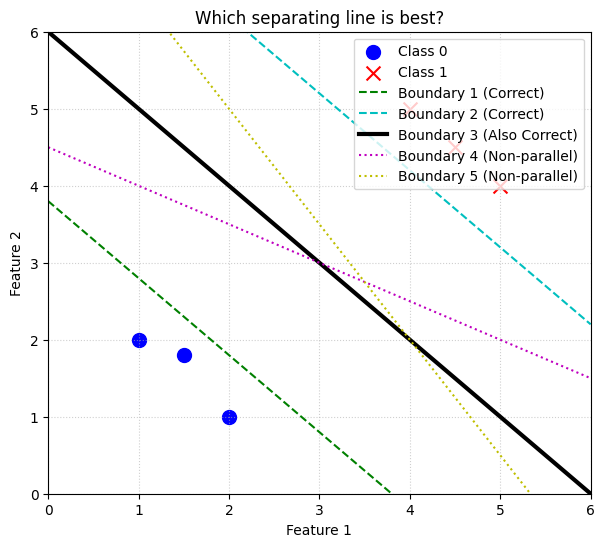

In [13]:
# 1. Create a simple, clearly separable dataset
X = np.array([
    [1, 2],  # Class 0
    [2, 1],  # Class 0
    [1.5, 1.8], # Class 0
    [4, 5],  # Class 1
    [5, 4],  # Class 1
    [4.5, 4.5] # Class 1
])

y = np.array([0, 0, 0, 1, 1, 1])

# Get the two classes
class_0 = X[y == 0]
class_1 = X[y == 1]

# 2. Plot the data
plt.figure(figsize=(7, 6))
plt.scatter(class_0[:, 0], class_0[:, 1], c='blue', marker='o', s=100, label='Class 0')
plt.scatter(class_1[:, 0], class_1[:, 1], c='red', marker='x', s=100, label='Class 1')

# 3. Define and plot multiple "correct" boundary lines
# We will create an array of x-values to plot our lines
x_line = np.linspace(0, 6, 100)

# Line 1: "Barely" separates, very close to Class 0
y_line_1 = -1 * x_line + 3.8
plt.plot(x_line, y_line_1, 'g--', label='Boundary 1 (Correct)')

# Line 2: "Barely" separates, very close to Class 1
y_line_2 = -1 * x_line + 8.2
plt.plot(x_line, y_line_2, 'c--', label='Boundary 2 (Correct)')

# Line 3: A "middle-of-the-road" parallel line
y_line_3 = -1 * x_line + 6
plt.plot(x_line, y_line_3, 'k-', linewidth=3, label='Boundary 3 (Also Correct)')

# Line 4: A new line with a different slope (shallower)
y_line_4 = -0.5 * x_line + 4.5
plt.plot(x_line, y_line_4, 'm:', label='Boundary 4 (Non-parallel)')

# Line 5: A new line with another different slope (steeper)
y_line_5 = -1.5 * x_line + 8
plt.plot(x_line, y_line_5, 'y:', label='Boundary 5 (Non-parallel)')


plt.title("Which separating line is best?")
plt.xlabel("Feature 1")
plt.ylabel("Feature 2")
plt.legend()
plt.grid(True, linestyle=':', alpha=0.6)
plt.xlim(0, 6)
plt.ylim(0, 6)
plt.show()

As you can see, all of these lines perfectly separate the data. But which one should we pick? This is the problem that SVM (Support Vector Machine) was designed to solve."

### 4.2. The SVM Objective: Maximizing the Margin

In the last example, we saw that for a simple dataset, there are *infinite* possible lines that can perfectly separate the two classes. This creates a problem: which line should we choose?

The objective of the **Support Vector Machine (SVM)** is to solve this ambiguity. It doesn't find just *any* line; it finds the **single best line**.

SVM defines the "best" line as the one that is **farthest from the data**, creating the widest possible "buffer zone" or "street" between the two classes. This buffer zone is called the **Margin**.

The goal of an SVM is to find the **optimal hyperplane that maximizes the margin** between the two classes.

**Why is this better?** A model with a larger margin is considered more **robust** and **generalizable**. It is less sensitive to the exact location of the training data and is more likely to correctly classify new, unseen data points because it has the largest possible "safety zone."

### 4.3. The Math of the Maximum Margin

To turn the idea of "maximizing the margin" into a solvable math problem, we need to define the hyperplane and the margin in mathematical terms.

#### 4.3.1. Defining the Hyperplane and Constraints

First, we define the decision boundary as a hyperplane. For a 2D dataset with features ($x_1, x_2$), this is a line, but in general, it's defined by a weight vector $w$ and a bias term $b$:

$$
w^T x + b = 0
$$

We then use a clever trick by *scaling* $w$ and $b$ so that the two "gutters" of our margin (the planes that touch the support vectors) are defined as:

1.  $w^T x + b = 1$ (for the positive class, $y_i = +1$)
2.  $w^T x + b = -1$ (for the negative class, $y_i = -1$)

This means that for a "hard margin" classifier, **every single data point must be on or outside these gutters**. We can combine these two rules into a single, elegant constraint for all data points $i$:

$$
y_i (w^T x_i + b) \ge 1
$$

This equation simply states that for *any* point, its class label ($y_i$) times its decision score ($w^T x_i + b$) must be a positive number greater than or equal to 1.

#### 4.3.2. The Objective (The Primal Problem)

With these planes defined, the perpendicular distance between them (the margin) can be calculated as:

$$
\text{Margin} = \frac{2}{||w||}
$$

Where $||w||$ is the L2-norm (magnitude) of the weight vector.

Our objective, "maximize the margin," is now a clear mathematical goal:

$$
\max_{w, b} \left( \frac{2}{||w||} \right)
$$

Maximizing $\frac{2}{||w||}$ is hard, but it's mathematically identical to **minimizing $||w||$**, which is, in turn, identical to **minimizing $\frac{1}{2} ||w||^2$**. (We use the squared term with $\frac{1}{2}$ because it's a "quadratic program" that is easy to differentiate and optimize).

This gives us the final **Primal Objective** of the SVM:

$$
\min_{w, b} \frac{1}{2} ||w||^2 \\
\text{subject to } y_i (w^T x_i + b) \ge 1 \text{ for all } i
$$

#### 4.3.3. The Dual Problem

Solving the constrained problem above is still difficult. The "solution" is found by transforming it into an equivalent problem called the **Dual Problem**, using a technique called Lagrange multipliers.

We introduce a new variable, $\alpha_i$, for each data point. The math is complex, but the original "primal" problem transforms into this new "dual" objective:

$$
\max_{\alpha} \left( \sum_{i=1}^n \alpha_i - \frac{1}{2} \sum_{i=1}^n \sum_{j=1}^n \alpha_i \alpha_j y_i y_j (x_i \cdot x_j) \right) \\
\text{subject to } \alpha_i \ge 0 \text{ and } \sum_{i=1}^n \alpha_i y_i = 0
$$

This looks *more* complicated, but it's the key to the SVM's power:

1.  **This is the "solution":** We are no longer solving for $w$; we are solving for the $\alpha$'s.
2.  **Finding Support Vectors:** It turns out that $\alpha_i$ will be **zero** for almost every data point, *except* for the **support vectors**, where $\alpha_i > 0$. The model automatically learns which points are the support vectors!
3.  **The Kernel Trick:** The *only* place the data appears is in the **dot product** $(x_i \cdot x_j)$. This is the magic key that allows us to later substitute this dot product with a "kernel function" to solve non-linear problems.

Once we solve for the $\alpha$'s, we can find our $w$ and $b$ to build the final classifier. The weight vector $w$ is simply a weighted sum of the support vectors:

$$
w = \sum_{i=1}^n \alpha_i y_i x_i
$$

### 4.4.  Support Vectors

The data points that lie on the edge of this margin (on the "curb") are called **Support Vectors**. They are the critical points that "support" or define the decision boundary. If you move any other point, the boundary won't change. If you move a support vector, the boundary *will* change.

This makes SVMs memory-efficient, as they only need to store the support vectors to make predictions.

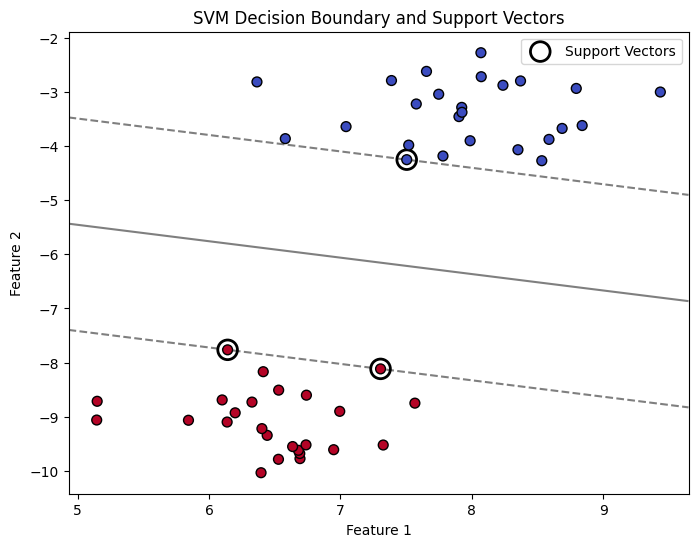

The model found 3 support vectors:
[[ 7.50523525 -4.24951586]
 [ 6.1417147  -7.7641028 ]
 [ 7.3059929  -8.11635767]]


In [14]:
# 1. Create a simple, clearly separable dataset
X, y = make_blobs(n_samples=50, centers=2, random_state=6, cluster_std=0.6)

# 2. Create and fit the SVM model
# We use kernel='linear' and a large C to create a hard margin
model = SVC(kernel='linear', C=1000)
model.fit(X, y)

# 3. Get the support vectors
# These are the data points that "support" the margin
support_vectors = model.support_vectors_

# --- Plotting ---
plt.figure(figsize=(8, 6))
ax = plt.gca()

# Plot all the data points
plt.scatter(X[:, 0], X[:, 1], c=y, s=50, cmap='coolwarm', zorder=10, edgecolors='k')

# 4. Plot the support vectors
# We highlight them with a larger, semi-transparent circle
ax.scatter(support_vectors[:, 0], support_vectors[:, 1], s=200,
           facecolors='none', edgecolors='k', linewidth=2, label='Support Vectors')

# --- Plot the decision boundary and margins ---
# Get the limits of the plot
xlim = ax.get_xlim()
ylim = ax.get_ylim()

# Create a grid to evaluate the model
xx = np.linspace(xlim[0], xlim[1], 30)
yy = np.linspace(ylim[0], ylim[1], 30)
YY, XX = np.meshgrid(yy, xx)
xy = np.vstack([XX.ravel(), YY.ravel()]).T

# Get the decision function (the distance from the hyperplane)
Z = model.decision_function(xy).reshape(XX.shape)

# Plot the decision boundary (Z=0) and the margins (Z=-1 and Z=1)
ax.contour(XX, YY, Z, colors='k', levels=[-1, 0, 1], alpha=0.5,
           linestyles=['--', '-', '--'])

plt.title("SVM Decision Boundary and Support Vectors")
plt.xlabel("Feature 1")
plt.ylabel("Feature 2")
plt.legend()
plt.show()

# 5. Print the support vectors
print("The model found {} support vectors:".format(len(support_vectors)))
print(support_vectors)

### 4.5. Soft Margin Classification: Handling Overlap

The original "maximal margin" idea (Hard Margin SVM) only works if the data is *perfectly* linearly separable and is very sensitive to outliers.

In reality, data is messy. **Soft Margin Classification** introduces flexibility.

-   It allows some points to be on the wrong side of the margin, or even on the wrong side of the decision boundary (a "margin violation").
-   It introduces a **`C` hyperparameter** (a regularization parameter).

**The `C` Hyperparameter:**

`C` controls the trade-off between maximizing the margin and minimizing misclassifications.

-   **Low `C`:** A "soft" margin. The model prioritizes a **wider margin**, even if it means misclassifying more points. This is **higher regularization** (prevents overfitting).
-   **High `C`:** A "hard" margin. The model prioritizes **classifying all points correctly**, even if it means a very narrow margin. This is **lower regularization** (can lead to overfitting).

### 4.5 The Kernel Trick: Handling Non-Linearity

**The Challenge:** What if the data is not linearly separable at all? (e.g., one class in a circle, the other class surrounding it). No straight line can separate this.

**The Solution: The Kernel Trick**

The kernel trick is a mathematically clever way to create non-linear decision boundaries.

The core idea is to **map the data to a higher-dimensional space** where a linear separation *does* become possible.

*Example:* Imagine 1D data `[x]` that is not linearly separable. If we map it to 2D using `[x, x^2]`, a simple line can now separate it.

A "kernel" is a function that *implicitly* computes the dot products between data points in this new, higher-dimensional space *without ever actually creating the new features*. This is computationally very efficient.

### Common Kernels:

-   **`kernel='linear'`:** This is just the standard linear SVM.
-   **`kernel='poly'` (Polynomial Kernel):** Captures polynomial relationships.
-   **`kernel='rbf'` (Radial Basis Function) Kernel:** The most popular and powerful choice. It can handle complex, non-linear relationships.

**The `gamma` Hyperparameter (for RBF Kernel):**

`gamma` defines how much influence a single training example has.

-   **Low `gamma`:** A wide, "smooth" Gaussian bell curve. A point has a large radius of influence. Leads to a **smoother, more general decision boundary** (higher regularization).
-   **High `gamma`:** A narrow, "spiky" Gaussian bell curve. A point's influence is very local. Leads to a **more complex, tight-fitting boundary** that can "island" individual points (lower regularization, risk of overfitting).

### 4.6 Implementation in Python (`sklearn.svm.SVC`)

Let's try SVM on two datasets: our original linear one, and a new, non-linear "moons" dataset.

**Crucial Prerequisite:** SVMs are **highly sensitive to feature scales**. The margin calculation depends on the distance between points. If one feature (e.g., "age" 20-80) has a much larger scale than another (e.g., "failure" 0-1), the high-scale feature will dominate the margin calculation.

**You MUST scale your data (e.g., with `StandardScaler`) before training an SVM.** We have already been doing this.

Linear SVM Model Accuracy: 1.0000


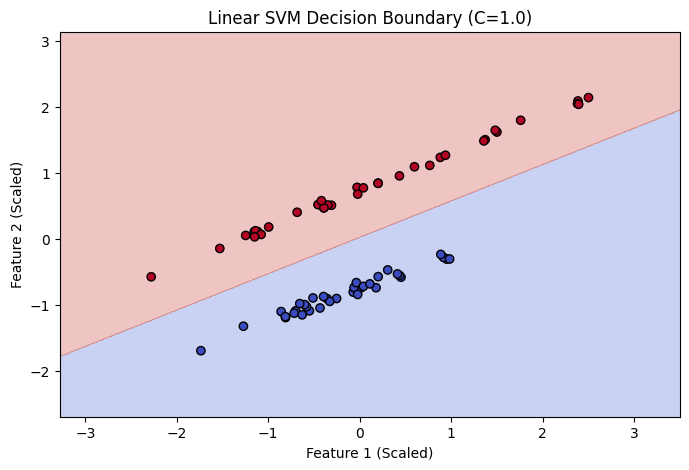

In [15]:
# 1. Train a linear SVM
# We use the same scaled data from before
linear_svm = SVC(kernel='linear', C=1.0)
linear_svm.fit(X_train_scaled, y_train)

# 2. Evaluate
y_pred_svm_linear = linear_svm.predict(X_test_scaled)
accuracy_svm_linear = accuracy_score(y_test, y_pred_svm_linear)
print(f'Linear SVM Model Accuracy: {accuracy_svm_linear:.4f}')

# 3. Plot boundary
plot_decision_boundary(linear_svm, X_train_scaled, y_train, 'Linear SVM Decision Boundary (C=1.0)')

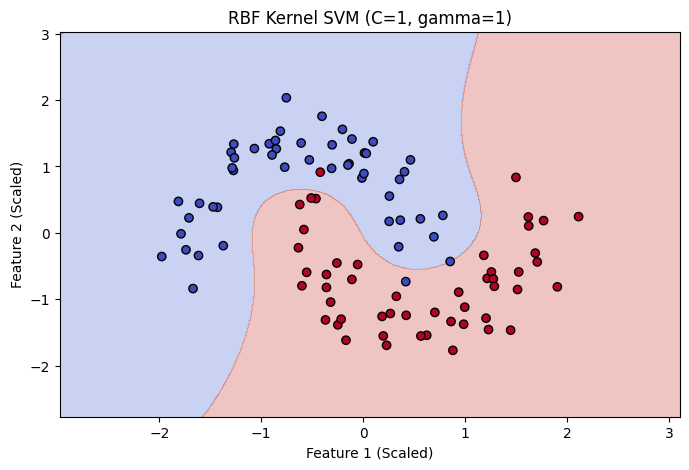

In [16]:
# Now, let's try a non-linear dataset
X_moons, y_moons = make_moons(n_samples=100, noise=0.15, random_state=42)

# Scale this new data
moon_scaler = StandardScaler()
X_moons_scaled = moon_scaler.fit_transform(X_moons)

# Train an RBF SVM
# We'll pick some default values for C and gamma
rbf_svm = SVC(kernel='rbf', C=1.0, gamma=1.0)
rbf_svm.fit(X_moons_scaled, y_moons)

# Plot the boundary
# We define a new plot function to handle the new data's scale
def plot_decision_boundary_moons(model, X, y, title):
    x_min, x_max = X[:, 0].min() - 1, X[:, 0].max() + 1
    y_min, y_max = X[:, 1].min() - 1, X[:, 1].max() + 1
    xx, yy = np.meshgrid(np.arange(x_min, x_max, 0.01),
                         np.arange(y_min, y_max, 0.01))

    Z = model.predict(np.c_[xx.ravel(), yy.ravel()])
    Z = Z.reshape(xx.shape)

    plt.figure(figsize=(8, 5))
    plt.contourf(xx, yy, Z, alpha=0.3, cmap=plt.cm.coolwarm)
    plt.scatter(X[:, 0], X[:, 1], c=y, cmap=plt.cm.coolwarm, edgecolors='k')
    plt.title(title)
    plt.xlabel('Feature 1 (Scaled)')
    plt.ylabel('Feature 2 (Scaled)')
    plt.show()

plot_decision_boundary_moons(rbf_svm, X_moons_scaled, y_moons, 'RBF Kernel SVM (C=1, gamma=1)')

Notice how the RBF kernel can create a complex, non-linear boundary.